<a href="https://colab.research.google.com/github/Rupashree0806/rupa-codeboosters-2026/blob/main/Day2/miniproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

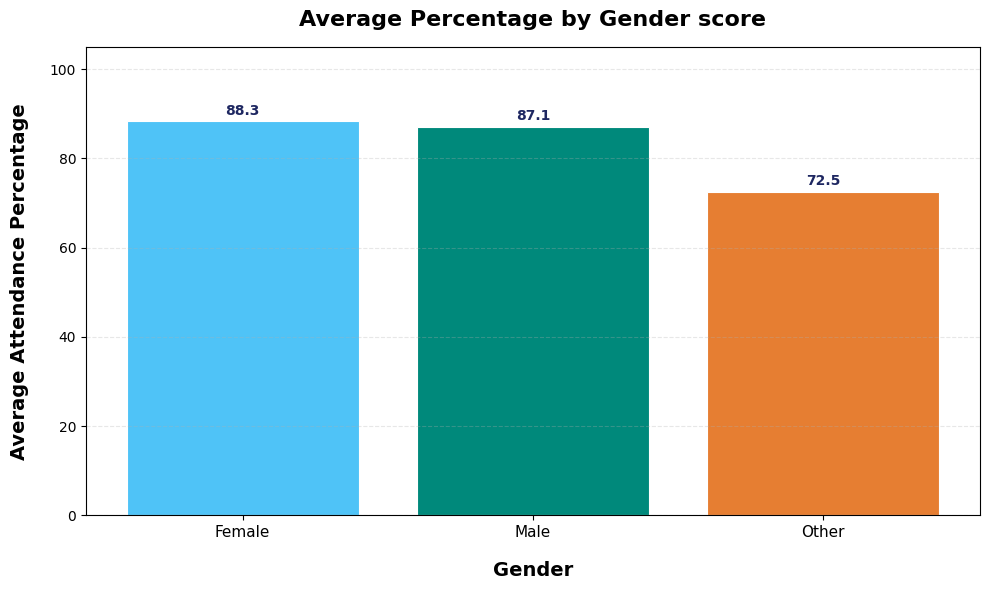

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Establish a database connection
conn = sqlite3.connect('your_database.db') # Replace 'your_database.db' with your actual database file

# Create a dummy 'students' table and insert data if it doesn't exist
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS students (
    student_id INTEGER PRIMARY KEY,
    gender TEXT,
    attendance_percentage REAL
);
''')

# Check if the table is empty and insert data if it is
cursor.execute('SELECT COUNT(*) FROM students')
if cursor.fetchone()[0] == 0:
    dummy_data = [
        ('Male', 85.5),
        ('Female', 92.1),
        ('Male', 78.9),
        ('Female', 88.2),
        ('Male', 95.0),
        ('Female', 81.3),
        ('Other', 70.0),
        ('Male', 89.0),
        ('Female', 91.5),
        ('Other', 75.0)
    ]
    cursor.executemany('INSERT INTO students (gender, attendance_percentage) VALUES (?, ?)', dummy_data)
    conn.commit()

chart1_sql="""
SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_percentage
FROM students
GROUP BY gender
ORDER BY avg_percentage DESC
"""
chart1_df=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['#4FC3F7','#00897B','#E67E32','#8E44AD'] # Corrected hex color code

bars=ax.bar(
    chart1_df['gender'], # Corrected variable name
    chart1_df['avg_percentage'],   # Corrected variable name
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
   height=bar.get_height()
   ax.text(
       bar.get_x()+bar.get_width()/2,
       height+0.8,
       f'{height:.1f}', # Changed to .1f for one decimal place
       ha='center',
       va='bottom',
       fontsize=10,
       fontweight='bold',
       color='#1E2761'
   )

ax.set_title('Average Percentage by Gender score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Gender',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylabel('Average Attendance Percentage',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

# Close the connection when done
conn.close()

In [ ]:
bar_colors = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars = ax.bar(
    chart1_df['gender'],
    chart1_df['avg_percentage'],
    color=bar_colors
)

ax.set_title("Average Attendance Percentage by Gender", fontweight='bold')
ax.set_ylabel("Average Attendance Percentage")

# VALUE LABELS
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        fontweight='bold'
    )

In [ ]:
df = pd.read_csv("student_performance.csv")

In [ ]:
conn = sqlite3.connect(':memory:')
df.to_sql(
    'students',
    conn,
    index=False,
    if_exists='replace'
)

30

In [ ]:
chart2_sql = """
SELECT department,
COUNT(*) AS total_students
FROM students
GROUP BY department
"""

chart2_df = pd.read_sql_query(chart2_sql, conn)

print(chart2_df)

         department  total_students
0             Civil               5
1  Computer Science              13
2       Electronics               6
3        Mechanical               6


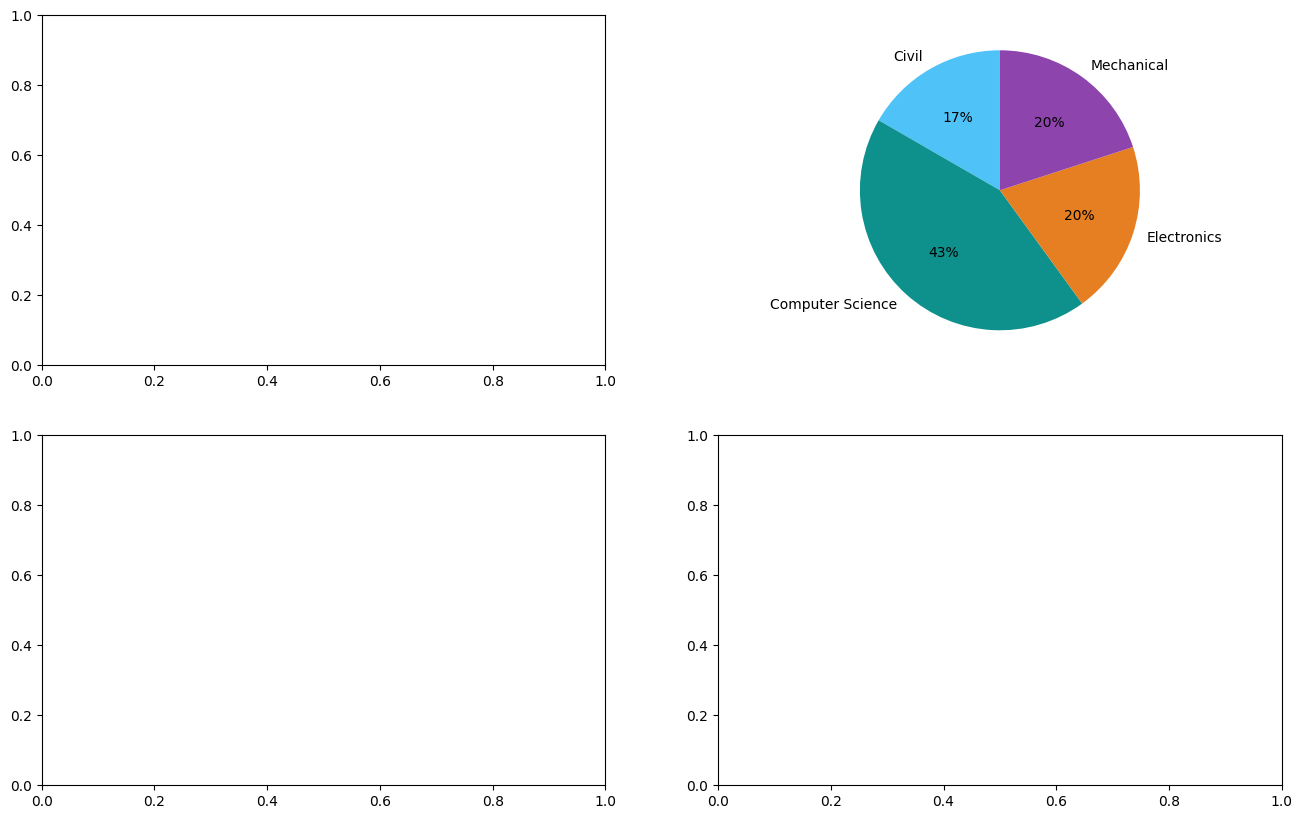

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

pie_colors = ['#4FC3F7','#0E918C','#E67E22','#8E44AD']

ax[0,1].pie(
    chart2_df['total_students'],
    labels=chart2_df['department'],
    autopct='%1.0f%%',
    colors=pie_colors,
    startangle=90
)

plt.show()

In [ ]:
print(df.columns)

Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')


In [ ]:
df['total_score'] = (
    df['math_score'] +
    df['programming_score']
)

In [ ]:
print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  total_score  
0                     92     Mumbai            2023          176  
1                     87  Ahmedabad 

In [ ]:
chart3_sql = """
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart3_df = pd.read_sql_query(chart3_sql, conn)

print(chart3_df)

DatabaseError: Execution failed on sql '
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
': no such column: total_score

In [ ]:
chart3_sql = """
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart3_df = pd.read_sql_query(chart3_sql, conn)

print(chart3_df)

DatabaseError: Execution failed on sql '
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
': no such column: total_score

In [ ]:
bars2 = ax[1,0].barh(
    chart3_df['name'],
    chart3_df['total_score'],
    color='#4FC3F7'
)

ax[1,0].set_title("Top 8 Students — Total Score", fontweight='bold')

ax[1,0].set_xlabel("Total Score (out of 400)")

ax[1,0].invert_yaxis()

# VALUE LABELS
for bar in bars2:
    width = bar.get_width()
    ax[1,0].text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontweight='bold',
        color='white'
    )

NameError: name 'chart3_df' is not defined